In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [16]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [17]:
# df['payment_terms'] = df['payment_terms'].astype(str).str.lower().str.strip()

In [18]:
# --- 1️⃣ Copy dataframe ---
df_encoded = df.copy()

# --- 2️⃣ Encode binary column ---
# df_encoded['inventory'] = df_encoded['inventory'].map({'Yes': 1, 'No': 0})

# df_encoded['status'] = df_encoded['status'].map({'Active': 1, 'Inactive': 0})

# df_encoded['sales_account'] = df_encoded['sales_account'].map({'1410873000000000388': 1, '1410873000025511653	': 0})

# --- 3️⃣ Encode target column ---
df_encoded['shipment_classified'] = df_encoded['shipment_classified'].map({'on_time': 0, 'delayed': 1})

# --- 4️⃣ Convert date columns ---
date_columns = ['eta','due_date','bill_date',]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='coerce')

# --- 5️⃣ Create derived time features ---
for col in date_columns:
  df_encoded[f'{col}_year'] = df_encoded[f'{col}'].dt.year
  df_encoded[f'{col}_year'] = df_encoded[f'{col}_year'].astype('str')
  df_encoded[f'{col}_month'] = df_encoded[f'{col}'].dt.month
  df_encoded[f'{col}_month'] = df_encoded[f'{col}_month'].astype('str')
  df_encoded[f'{col}_day'] = df_encoded[col].dt.day
  df_encoded[f'{col}_day'] = df_encoded[f'{col}_day'].astype('str')
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}'].dt.weekday
  df_encoded[f'{col}_weekday'] = df_encoded[f'{col}_weekday'].astype('str')

# df_encoded['shipment_duration'] = (pd.to_datetime(df_encoded['receipt_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['expected_delay'] = (pd.to_datetime(df['receipt_date']) - pd.to_datetime(df['eta'])).dt.days
df_encoded['due_gap'] = (pd.to_datetime(df_encoded['due_date']) - pd.to_datetime(df_encoded['bill_date'])).dt.days
# df['weekday_bill'] = pd.to_datetime(df['bill_date']).dt.weekday
# df['month_bill'] = pd.to_datetime(df['bill_date']).dt.month

# df_encoded['shipped_day'] = df_encoded['shipped_date'].dt.day
# df_encoded['shipped_month'] = df_encoded['shipped_date'].dt.month
# df_encoded['shipped_year'] = df_encoded['shipped_date'].dt.year
# df_encoded['shipped_weekday'] = df_encoded['shipped_date'].dt.weekday

# --- 6️⃣ Shipping delay feature ---
# df_encoded['delay_days'] = (df_encoded['eta'] - df_encoded['shipped_date']).dt.days

# # --- 7️⃣ Drop raw date columns ---
df_encoded.drop(date_columns + ['receipt_date'], axis=1, inplace=True)

# these feature engineering cannot be applied due to high missing values
# df_encoded['value_per_unit'] = df_encoded['purchase_price'] / df_encoded['quantity_in']
# df_encoded['profit_margin'] = (df_encoded['sales_price'] - df_encoded['purchase_price']) / df_encoded['purchase_price']
# df_encoded['stock_after_shipment'] = df_encoded['opening_stock'] - df_encoded['quantity_in']

df_encoded['broker_frequency'] = df_encoded['customs_broker'].map(df_encoded['customs_broker'].value_counts())

df_encoded.drop(['customs_broker'], axis=1, inplace=True)

# --- 8️⃣ Handle categorical columns ---
categorical_cols = [ 'seal']
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    if df_encoded[col].nunique() > 100:  
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    else:
        df_encoded = pd.get_dummies(df_encoded, columns=[col], drop_first=True, dtype=int)


# --- 9️⃣ Scale numeric features (optional for ML models like logistic regression) ---
# numeric_cols = ['discount', 'delay_days']
# scaler = StandardScaler()
# df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# # --- 🔟 Final encoded dataset ---
# print(df_encoded.head())

# X, y split for training
X = df_encoded.drop('shipment_classified', axis=1)
y = df_encoded['shipment_classified']


In [19]:
# Step 2: Data preprocessing
# df['inventory'] = df['inventory'].map({'Yes': 1, 'No': 0})
# df['shipment_classified'] = df['shipment_classified'].map({'on_time': 0, 'delayed': 1})

In [20]:
# Encode categorical columns
# cat_cols = df.select_dtypes(include=['object']).columns
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col])

In [21]:
# df_encoded['sales_price'].value_counts()

In [22]:
# # Step 3: Split features & target
# X = df.drop('shipment_classified', axis=1)
# y = df['shipment_classified']

In [23]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# Step 5: Scale features
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [25]:
# Step 6: Train model
model = DecisionTreeClassifier(splitter="best",class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [26]:
# Step 7: Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8683473389355743

Confusion Matrix:
 [[267  26]
 [ 21  43]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       293
           1       0.62      0.67      0.65        64

    accuracy                           0.87       357
   macro avg       0.78      0.79      0.78       357
weighted avg       0.87      0.87      0.87       357



In [27]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop features influencing delay:\n", importance.head(10))


Top features influencing delay:
 eta_weekday          0.182788
bill_date_weekday    0.124578
eta_day              0.088390
eta_year             0.074693
seal                 0.072267
due_date_day         0.066962
quantity_in          0.054910
bill_date_day        0.054593
bill_date_month      0.049213
due_date_year        0.048678
dtype: float64


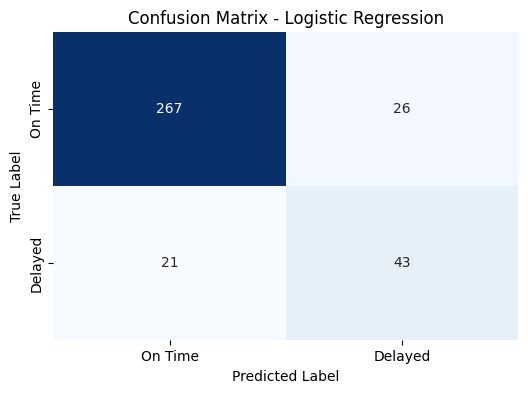

In [28]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()